# Hospital Stay Prediction

## <b><font color= 'red'> Problem Statement </font></b>
#### Hospitals need to predict how long a patient may stay after admission. Accurate prediction helps hospitals in:

 - Bed management
 - Resource allocation
 - Staff planning
 - Emergency preparedness
 - Reducing operational cost

#### The goal is to build a Machine Learning model that predicts the Length of Stay (LOS) of patients using hospital and patient-related features.

# <b><font color= 'red'> Objective </font></b>
- Improve hospital resource utilization.
- Optimize bed allocation.
- Improve patient management.
- Reduce operational cost.
- Assist healthcare decision making.

### <font color='green'> Importing some important libraries </font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import warnings 
warnings.filterwarnings('ignore')

### <font color='green'> EDA (Exploratory Data Analysis) </font>

In [2]:
# storing the data into a variable
df = pd.read_csv('HealthCareAnalytics.csv')

In [3]:
#check first 10 records
df.head(10)

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558,41-50
5,6,23,a,6,X,2,anesthesia,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,4449,Nov-20
6,7,32,f,9,Y,1,radiotherapy,S,B,3.0,31397,7.0,Emergency,Extreme,2,51-60,6167,0-10
7,8,23,a,6,X,4,radiotherapy,Q,F,3.0,31397,7.0,Trauma,Extreme,2,51-60,5571,41-50
8,9,1,d,10,Y,2,gynecology,R,B,4.0,31397,7.0,Trauma,Extreme,2,51-60,7223,51-60
9,10,10,e,1,X,2,gynecology,S,E,3.0,31397,7.0,Trauma,Extreme,2,51-60,6056,31-40


In [4]:
#check last 5 records
df.tail(5)

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
318433,318434,6,a,6,X,3,radiotherapy,Q,F,4.0,86499,23.0,Emergency,Moderate,3,41-50,4144,Nov-20
318434,318435,24,a,1,X,2,anesthesia,Q,E,4.0,325,8.0,Urgent,Moderate,4,81-90,6699,31-40
318435,318436,7,a,4,X,3,gynecology,R,F,4.0,125235,10.0,Emergency,Minor,3,71-80,4235,Nov-20
318436,318437,11,b,2,Y,3,anesthesia,Q,D,3.0,91081,8.0,Trauma,Minor,5,Nov-20,3761,Nov-20
318437,318438,19,a,7,Y,5,gynecology,Q,C,2.0,21641,8.0,Emergency,Minor,2,Nov-20,4752,0-10


### Observation
- Dataset contains demographic, hospital and patient related information.
- Target variable is Stay.
- Both categorical and numerical columns are present.

In [5]:
#checking the null values
df.isnull().sum()

case_id                                 0
Hospital_code                           0
Hospital_type_code                      0
City_Code_Hospital                      0
Hospital_region_code                    0
Available_Extra_Rooms_in_Hospital       0
Department                              0
Ward_Type                               0
Ward_Facility_Code                      0
Bed_Grade                             113
patientid                               0
City_Code_Patient                    4532
Type_of_Admission                       0
Severity_of_Illness                     0
Visitors_with_Patient                   0
Age                                     0
Admission_Deposit                       0
Stay                                    0
dtype: int64

In [6]:
# Filling null values
df['Bed_Grade'].fillna(df['Bed_Grade'].mode()[0], inplace=True)

In [7]:
# Filling null values
df['City_Code_Patient'].fillna(df['City_Code_Patient'].mode()[0], inplace=True)

In [8]:
# Checking again the null values
df.isnull().sum()

case_id                              0
Hospital_code                        0
Hospital_type_code                   0
City_Code_Hospital                   0
Hospital_region_code                 0
Available_Extra_Rooms_in_Hospital    0
Department                           0
Ward_Type                            0
Ward_Facility_Code                   0
Bed_Grade                            0
patientid                            0
City_Code_Patient                    0
Type_of_Admission                    0
Severity_of_Illness                  0
Visitors_with_Patient                0
Age                                  0
Admission_Deposit                    0
Stay                                 0
dtype: int64

#### Missing Value Handling
##### - Bed_Grade column contained very few missing values.
##### - Since it is a categorical feature, missing values were replaced using mode imputation.
##### - City_Code_Patient also contained missing values.
##### - As it represents encoded city categories, mode imputation was used instead of deleting rows to preserve dataset size.

In [9]:
#checking the shape of the data set
df.shape

(318438, 18)

In [10]:
# collecting the information about the data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318438 entries, 0 to 318437
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   case_id                            318438 non-null  int64  
 1   Hospital_code                      318438 non-null  int64  
 2   Hospital_type_code                 318438 non-null  object 
 3   City_Code_Hospital                 318438 non-null  int64  
 4   Hospital_region_code               318438 non-null  object 
 5   Available_Extra_Rooms_in_Hospital  318438 non-null  int64  
 6   Department                         318438 non-null  object 
 7   Ward_Type                          318438 non-null  object 
 8   Ward_Facility_Code                 318438 non-null  object 
 9   Bed_Grade                          318438 non-null  float64
 10  patientid                          318438 non-null  int64  
 11  City_Code_Patient                  3184

In [11]:
df.columns

Index(['case_id', 'Hospital_code', 'Hospital_type_code', 'City_Code_Hospital',
       'Hospital_region_code', 'Available_Extra_Rooms_in_Hospital',
       'Department', 'Ward_Type', 'Ward_Facility_Code', 'Bed_Grade',
       'patientid', 'City_Code_Patient', 'Type_of_Admission',
       'Severity_of_Illness', 'Visitors_with_Patient', 'Age',
       'Admission_Deposit', 'Stay'],
      dtype='object')

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
case_id,318438.0,159219.500000,91925.276847,1.0,79610.25,159219.5,238828.75,318438.0
Hospital_code,318438.0,18.318841,8.633755,1.0,11.00,19.0,26.00,32.0
City_Code_Hospital,318438.0,4.771717,3.102535,1.0,2.00,5.0,7.00,13.0
Available_Extra_Rooms_in_Hospital,318438.0,3.197627,1.168171,0.0,2.00,3.0,4.00,24.0
Bed_Grade,318438.0,2.625585,0.873070,1.0,2.00,3.0,3.00,4.0
patientid,318438.0,65747.579472,37979.936440,1.0,32847.00,65724.5,98470.00,131624.0
City_Code_Patient,318438.0,7.262506,4.712210,1.0,4.00,8.0,8.00,38.0
Visitors_with_Patient,318438.0,3.284099,1.764061,0.0,2.00,3.0,4.00,32.0
Admission_Deposit,318438.0,4880.749392,1086.776254,1800.0,4186.00,4741.0,5409.00,11008.0


In [13]:
# checking duplicate values
df.duplicated().sum()

np.int64(0)

## <font color='red'>Visualization</font>

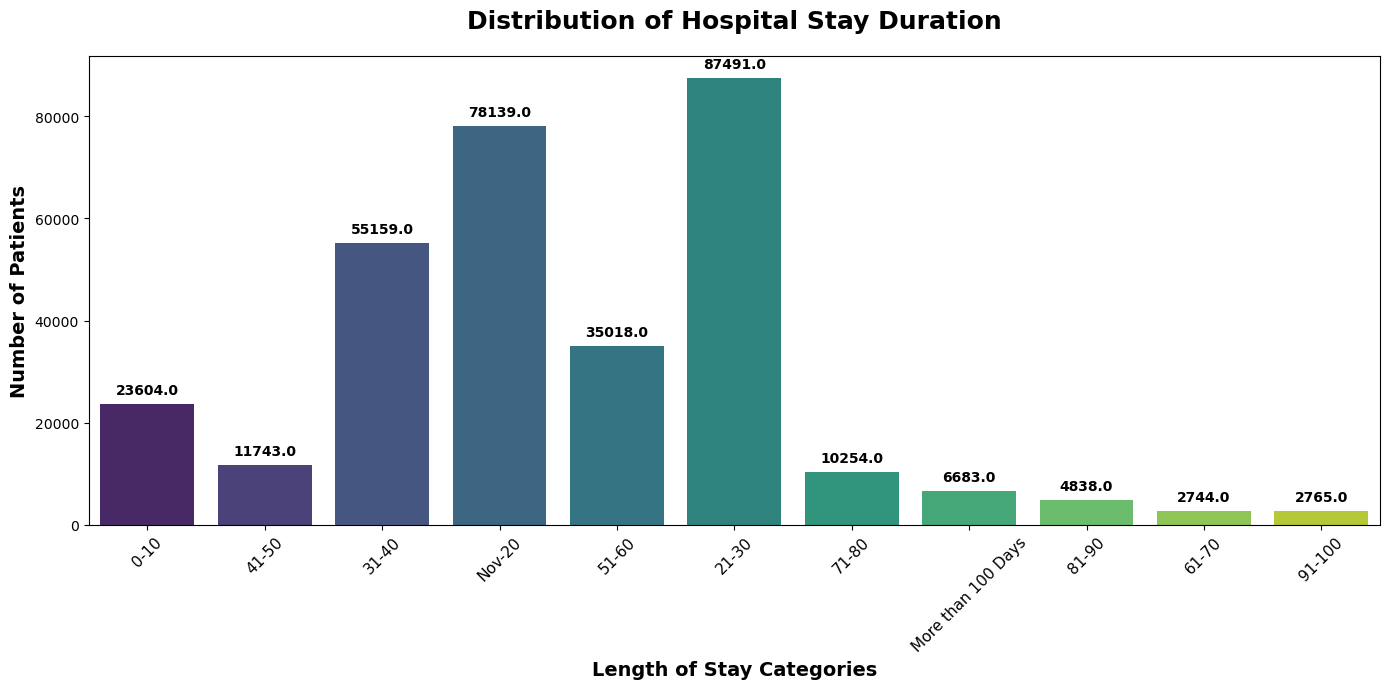

In [14]:
# Target Variable Distribution
# Figure Size
plt.figure(figsize=(14,7))

# Count Plot
ax = sns.countplot(
    x='Stay',
    data=df,
    palette='viridis'
)

# Title
plt.title(
    "Distribution of Hospital Stay Duration",
    fontsize=18,
    fontweight='bold',
    pad=20
)

# X-axis Label
plt.xlabel(
    "Length of Stay Categories",
    fontsize=14,
    fontweight='bold'
)

# Y-axis Label
plt.ylabel(
    "Number of Patients",
    fontsize=14,
    fontweight='bold'
)

# Rotate X labels
plt.xticks(rotation=45, fontsize=11)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black',
        xytext=(0,5),
        textcoords='offset points'
    )

# Grid for better readability
#plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tight Layout
plt.tight_layout()

# Show Plot
plt.show()

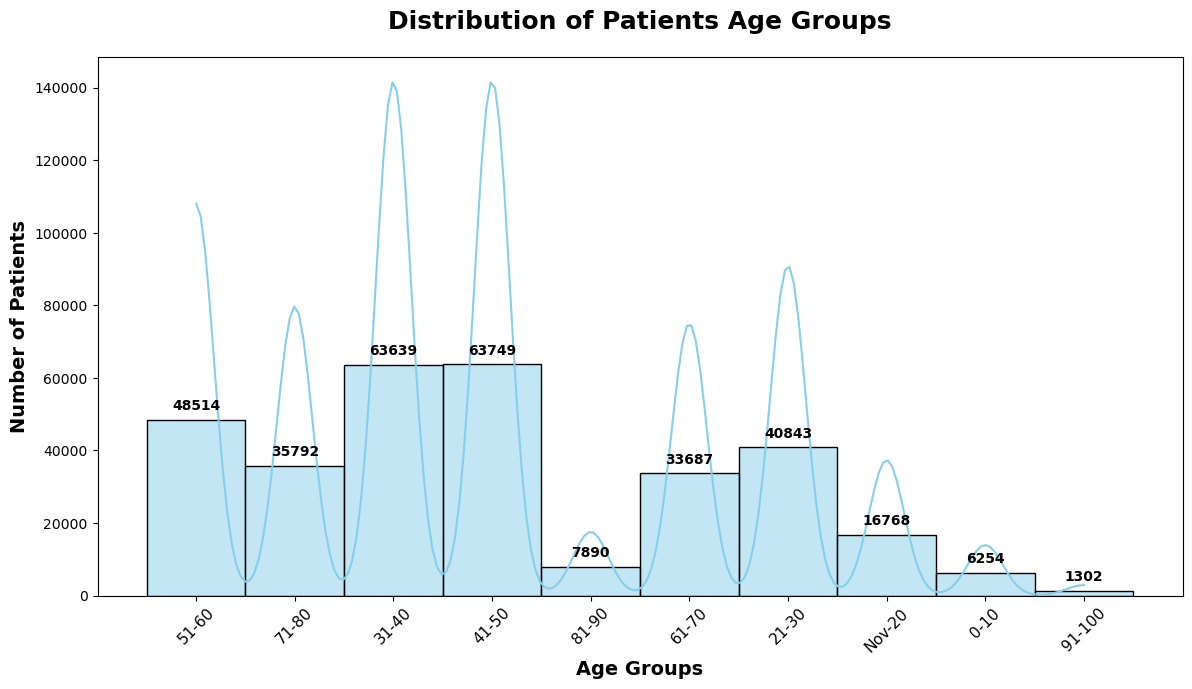

In [15]:
# Age Distribution

# Figure Size
plt.figure(figsize=(14,7))

# Histogram Plot
ax = sns.histplot(
    data=df,
    x='Age',
    bins=20,
    kde=True,
    color='skyblue'
)

# Title
plt.title(
    "Distribution of Patients Age Groups",
    fontsize=18,
    fontweight='bold',
    pad=20
)

# X-axis Label
plt.xlabel(
    "Age Groups",
    fontsize=14,
    fontweight='bold'
)

# Y-axis Label
plt.ylabel(
    "Number of Patients",
    fontsize=14,
    fontweight='bold'
)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black',
        xytext=(0,5),
        textcoords='offset points'
    )
    
# Rotate labels for better visibility
plt.xticks(rotation=45, fontsize=11)

# Show Plot
plt.show()

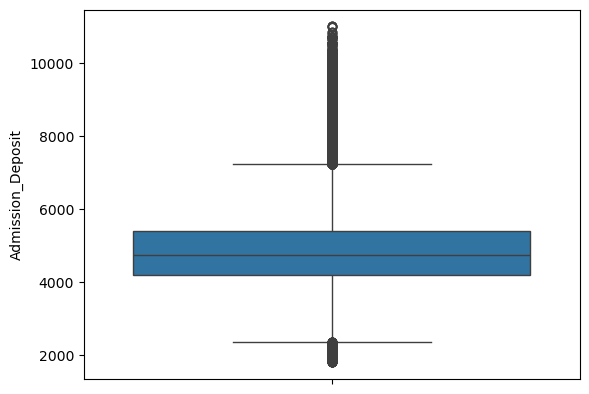

In [16]:
# Admission Deposit
# Figure Size
sns.boxplot(df['Admission_Deposit'])

plt.show()

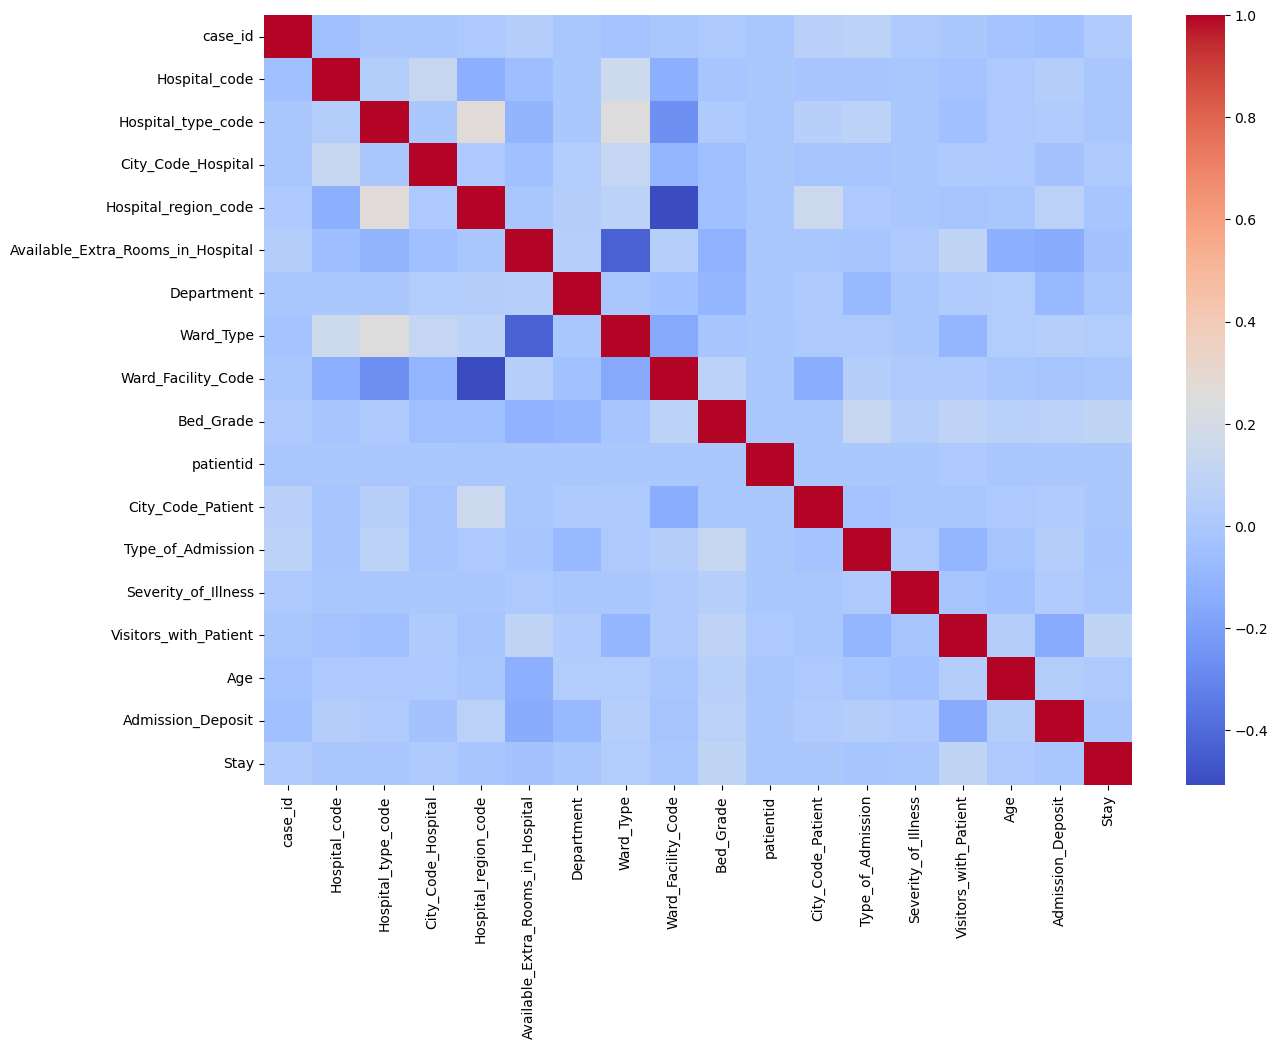

In [43]:
# Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(
df.corr(numeric_only=True),
cmap='coolwarm'
)
plt.show()

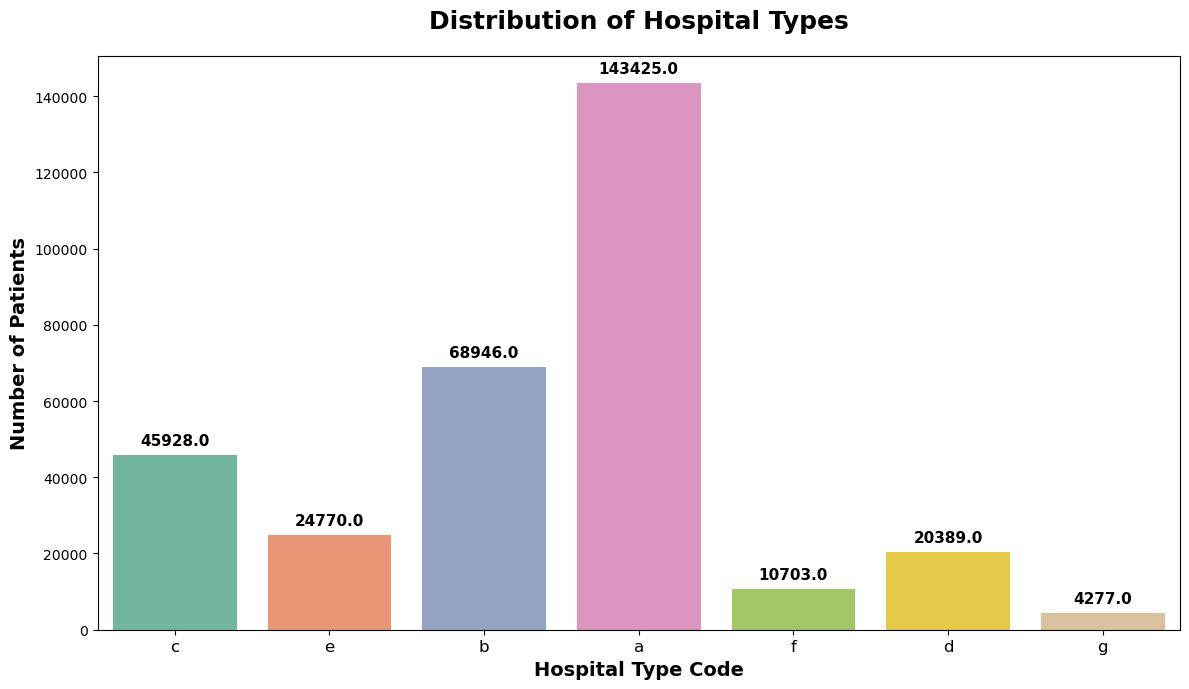

In [19]:
# Hospital Type Analysis
# Figure Size
plt.figure(figsize=(12,7))

# Count Plot
ax = sns.countplot(
    x='Hospital_type_code',
    data=df,
    palette='Set2'
)

# Title
plt.title(
    "Distribution of Hospital Types",
    fontsize=18,
    fontweight='bold',
    pad=20
)

# X-axis Label
plt.xlabel(
    "Hospital Type Code",
    fontsize=14,
    fontweight='bold'
)

# Y-axis Label
plt.ylabel(
    "Number of Patients",
    fontsize=14,
    fontweight='bold'
)

# X-axis label formatting
plt.xticks(fontsize=12)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='black',
        xytext=(0,5),
        textcoords='offset points'
    )

# Tight Layout
plt.tight_layout()

# Show Plot
plt.show()

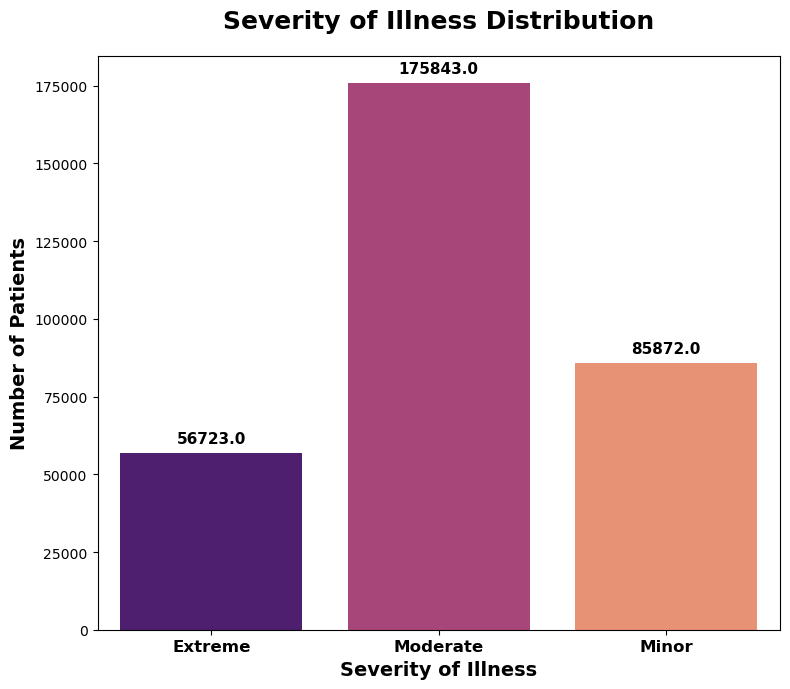

In [20]:
# Admission Type Analysis

# Figure Size
plt.figure(figsize=(8,7))

# Count Plot
ax = sns.countplot(
    x='Severity_of_Illness',
    data=df,
    palette='magma'
)

# Title
plt.title(
    "Severity of Illness Distribution",
    fontsize=18,
    fontweight='bold',
    pad=20
)

# X-axis Label
plt.xlabel(
    "Severity of Illness",
    fontsize=14,
    fontweight='bold'
)

# Y-axis Label
plt.ylabel(
    "Number of Patients",
    fontsize=14,
    fontweight='bold'
)

# X-axis tick labels
plt.xticks(
    rotation=0,
    fontsize=12,
    fontweight='bold'
)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='black',
        xytext=(0,5),
        textcoords='offset points'
    )

# Tight Layout
plt.tight_layout()

# Show Plot
plt.show()

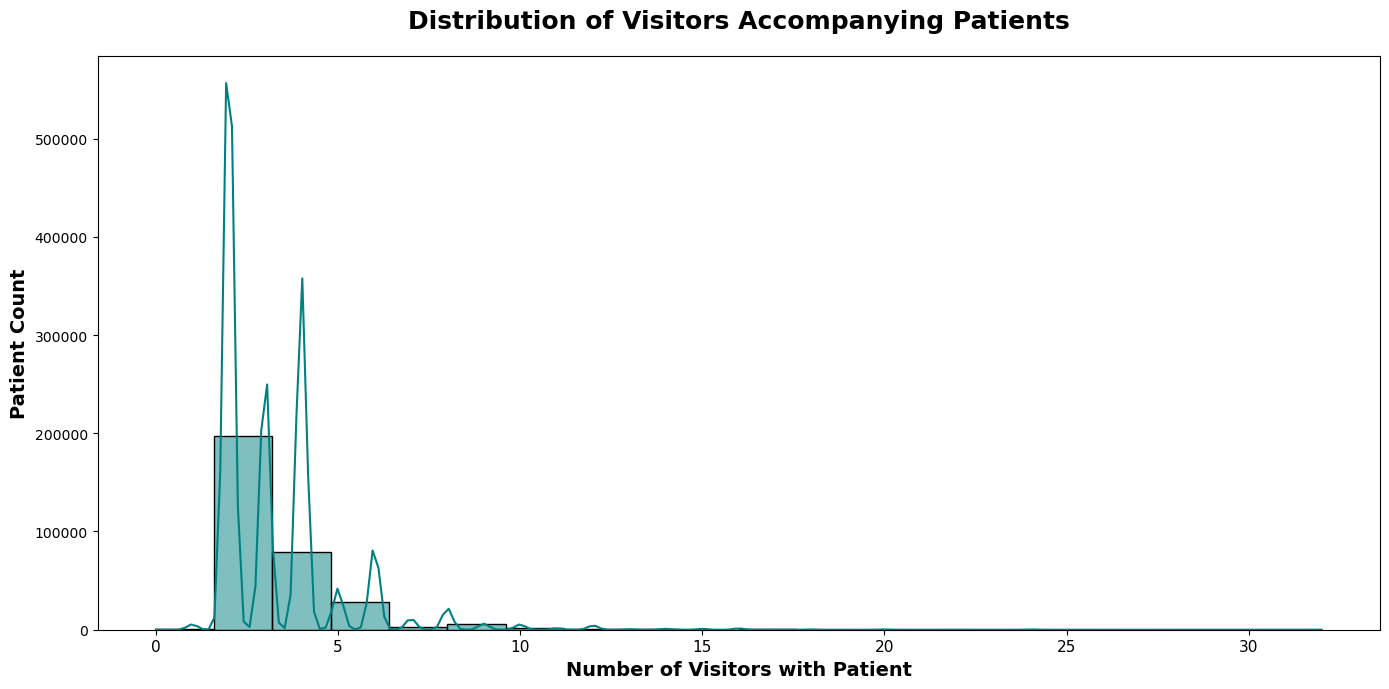

In [21]:
# Visitors Analysis

# Figure Size
plt.figure(figsize=(14,7))

# Histogram Plot
ax = sns.histplot(
    data=df,
    x='Visitors_with_Patient',
    bins=20,
    kde=True,
    color='teal'
)

# Title
plt.title(
    "Distribution of Visitors Accompanying Patients",
    fontsize=18,
    fontweight='bold',
    pad=20
)

# X-axis Label
plt.xlabel(
    "Number of Visitors with Patient",
    fontsize=14,
    fontweight='bold'
)

# Y-axis Label
plt.ylabel(
    "Patient Count",
    fontsize=14,
    fontweight='bold'
)

# X-axis tick formatting
plt.xticks(fontsize=11)

# Tight Layout
plt.tight_layout()

# Show Plot
plt.show()

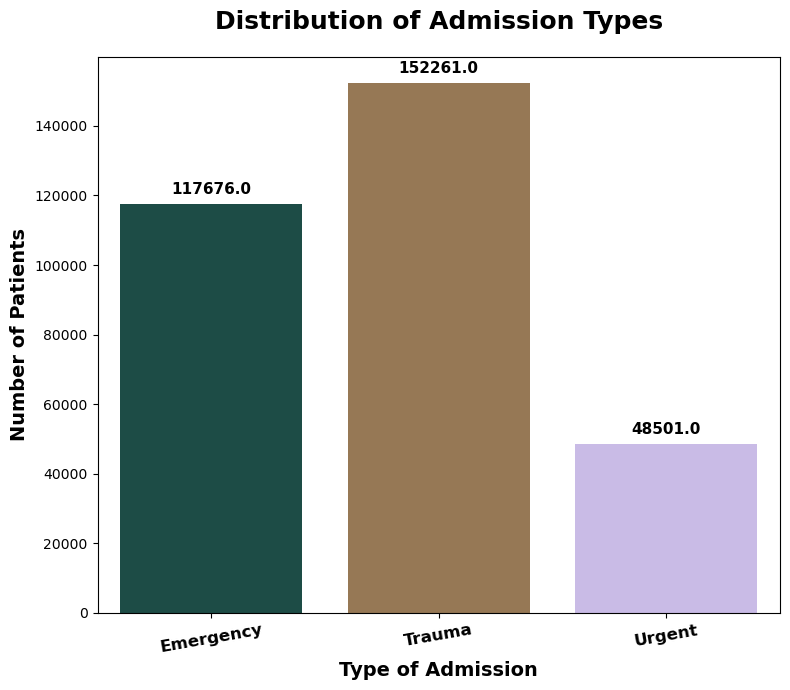

In [22]:
# Admission Type Analysis

# Figure Size
plt.figure(figsize=(8,7))

# Count Plot
ax = sns.countplot(
    x='Type_of_Admission',
    data=df,
    palette='cubehelix'
)

# Title
plt.title(
    "Distribution of Admission Types",
    fontsize=18,
    fontweight='bold',
    pad=20
)

# X-axis Label
plt.xlabel(
    "Type of Admission",
    fontsize=14,
    fontweight='bold'
)

# Y-axis Label
plt.ylabel(
    "Number of Patients",
    fontsize=14,
    fontweight='bold'
)

# X-axis tick formatting
plt.xticks(
    rotation=10,
    fontsize=12,
    fontweight='bold'
)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='black',
        xytext=(0,5),
        textcoords='offset points'
    )

# Tight Layout
plt.tight_layout()

# Show Plot
plt.show()

In [23]:
# Label Encoding
le = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [24]:
# Feature Selection
X = df.drop('Stay', axis=1)
y = df['Stay']

In [25]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# <font color='red'>Model Building</font>

### <font color='Green'>Logistic Regression</font>

In [51]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.2808535359879412


### <font color='Green'>Decision Tree</font>

In [53]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.29975819620650673


### <font color='Green'>Random Forest</font>

In [56]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.4169859314156513


### <font color='Green'>XGBoost</font>

In [57]:
xgb = XGBClassifier()

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.42582590126868486


### <font color='Green'>Confusion Matrix</font>

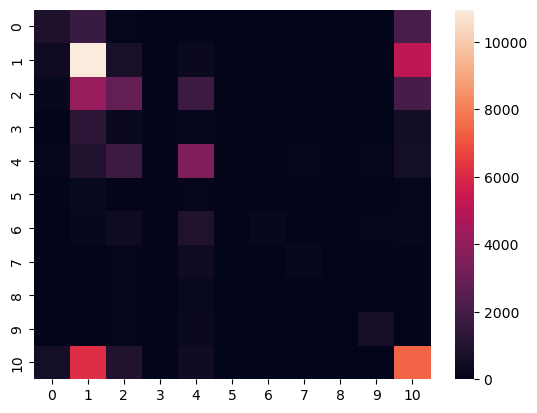

In [30]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm)

plt.show()

In [31]:
# Classification Report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.36      0.17      0.23      4689
           1       0.43      0.62      0.51     17603
           2       0.38      0.25      0.30     10981
           3       0.16      0.01      0.02      2357
           4       0.42      0.49      0.46      7128
           5       0.62      0.01      0.03       554
           6       0.45      0.09      0.15      2031
           7       0.46      0.20      0.28       941
           8       0.68      0.09      0.16       552
           9       0.59      0.48      0.53      1291
          10       0.41      0.47      0.44     15561

    accuracy                           0.42     63688
   macro avg       0.45      0.26      0.28     63688
weighted avg       0.41      0.42      0.39     63688



In [32]:
# Feature Importance
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
16,Admission_Deposit,0.157995
0,case_id,0.153563
10,patientid,0.149653
14,Visitors_with_Patient,0.084070
15,Age,0.081575
11,City_Code_Patient,0.073754
5,Available_Extra_Rooms_in_Hospital,0.051844
1,Hospital_code,0.038877
9,Bed_Grade,0.035334
7,Ward_Type,0.033757


In [35]:
import pickle

pickle.dump(rf, open('random_forest.pkl', 'wb'))

# <font color='Red'>Hyperparameter Tuning</font>

## <font color='Green'>Random Forest Tuning</font>

In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = {

'n_estimators':[100,200],

'max_depth':[10,20,None],

'min_samples_split':[2,5]

}

grid = GridSearchCV(
RandomForestClassifier(),
param_grid,
cv=3,
n_jobs=-1
)

grid.fit(
X_train,
y_train
)

grid.best_params_

{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}

In [46]:
# Best Model
best_rf = grid.best_estimator_

# <font color='Red'>Model Comparison Report</font>

## <font color='Green'>Compare Models</font>

In [58]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        lr_acc,
        dt_acc,
        rf_acc,
        xgb_acc
    ]
})

comparison.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
3,XGBoost,0.425826
2,Random Forest,0.416986
1,Decision Tree,0.299758
0,Logistic Regression,0.280854


## EDA Insights
###### Example:
- Patients with severe illness stayed longer.
- Higher admission deposits correlated with longer stays.
- Emergency admissions had longer hospitalization periods.

## Best Model
###### Example:
- Random Forest achieved highest accuracy.
- It handled categorical and nonlinear data efficiently.

## Challenges Faced
- Missing Values - Mode/Median Imputation
- Categorical Data	- Label Encoding
- Imbalanced Classes - Model tuning
- Overfitting - Ensemble Models / Random Forest & XGBoost
- High Dimensional Features - Feature Selection

## Suggestions
- Collect more clinical features.
- Include diagnosis details.
- Perform advanced feature engineering.
- Use CatBoost and LightGBM.
- Deploy using Streamlit.

## <font color='Red'>Conclusion</font>
- Multiple machine learning models were developed to predict hospital stay duration.
- Random Forest and XGBoost outperformed traditional models due to their ability to capture nonlinear patterns and interactions among features.
- The final model can help hospitals improve bed allocation, staff planning and operational efficiency.